In [18]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict, Literal
import numpy as np

In [24]:
class QuadraticEqInput(TypedDict):
    a: float
    b: float
    c: float

    eq: str
    discriminant:float
    result: str

# Func_1
def show_equation(state: QuadraticEqInput)->QuadraticEqInput:

    equation = f"{state['a']}X**2 + {state['b']}X +{state['c']}"

    return {'eq':equation}

# Func_2
def calculate_discriminant(state: QuadraticEqInput)->QuadraticEqInput:

    D = (state['b'])**2 - 4 * (state['a']) * (state['c'])

    return {'discriminant':D}

# Func_3
def no_real_root(state: QuadraticEqInput)->QuadraticEqInput:

    if state['discriminant'] < 0:

        output = f"No Real Roots for Quadratic Equation: {state['eq']}. As, Discriminant: {state['discriminant']} is less than 0."

    return {'result':output}

# Func_4
def distinct_root(state: QuadraticEqInput)->QuadraticEqInput:

    r1 = float((-state['b'] + np.sqrt(state['discriminant']))/(2*state['a']))
    r2 = float((-state['b'] - np.sqrt(state['discriminant']))/(2*state['a']))

    output = f"The roots are {r1} & {r2}."

    return {'result':output}

# Func_5
def repeated_root(state: QuadraticEqInput)->QuadraticEqInput:

    root = (-state['b'])/(2*state['a'])

    output = f"Repeating roots only, {root}."

    return {'result':output}

# Func_6
def check_roots(state: QuadraticEqInput)->Literal["distinct_root", "repeated_root", "no_real_root"]:

    D = state['discriminant']

    if D == 0:
        return "repeated_root"
    elif D > 0:
        return "distinct_root"
    else:
        return "no_real_root"

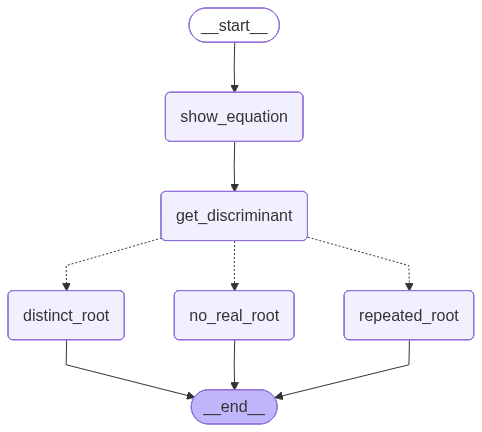

In [25]:
# Define state graph
graph = StateGraph(QuadraticEqInput)

# add node
graph.add_node("show_equation", show_equation)
graph.add_node("get_discriminant", calculate_discriminant)
graph.add_node("no_real_root", no_real_root)
graph.add_node("distinct_root", distinct_root)
graph.add_node("repeated_root", repeated_root)

#add edges
graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','get_discriminant')

# conditional edges
graph.add_conditional_edges('get_discriminant', check_roots)

graph.add_edge('no_real_root',END)
graph.add_edge('distinct_root',END)
graph.add_edge('repeated_root',END)

# compile and create workflow
workflow=graph.compile()
workflow

In [ ]:
ini_state={
    'a':4, 
    'b':2,  
    'c':5
}

workflow.invoke(ini_state)

{'a': 4,
 'b': 2,
 'c': 5,
 'eq': '4X**2 + 2X +5',
 'discriminant': -76,
 'result': 'No Real Roots for Quadratic Equation: 4X**2 + 2X +5. As, Discriminant: -76 is less than 0.'}